Importar librerías

In [247]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


Cargar datos

In [248]:
url = "https://github.com/ulewis/Ejemplos/raw/main/Datos/healthcare_dataset.csv"
df = pd.read_csv(url)

In [249]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


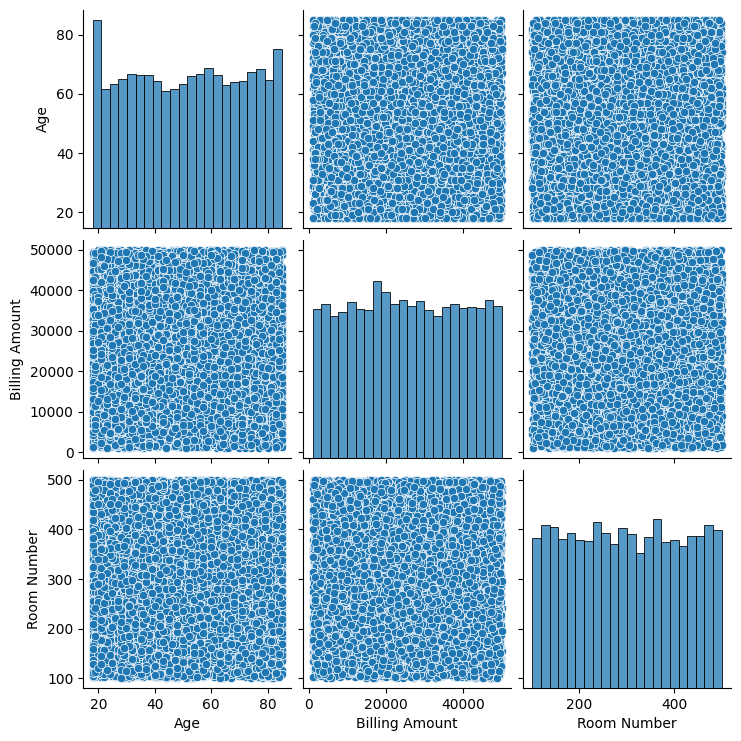

In [250]:
sns.pairplot(df)

<Axes: ylabel='Frequency'>

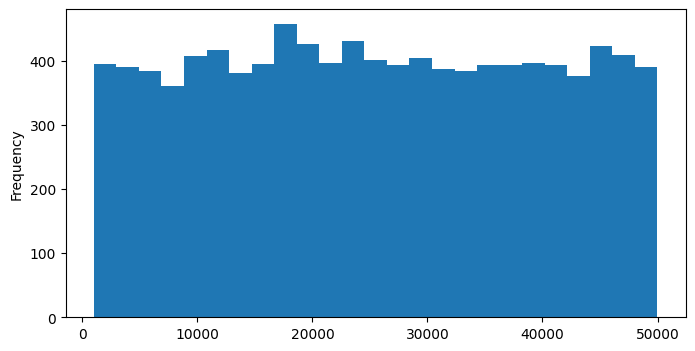

In [251]:
df['Billing Amount'].plot.hist(bins=25,figsize=(8,4))

<Axes: ylabel='Density'>

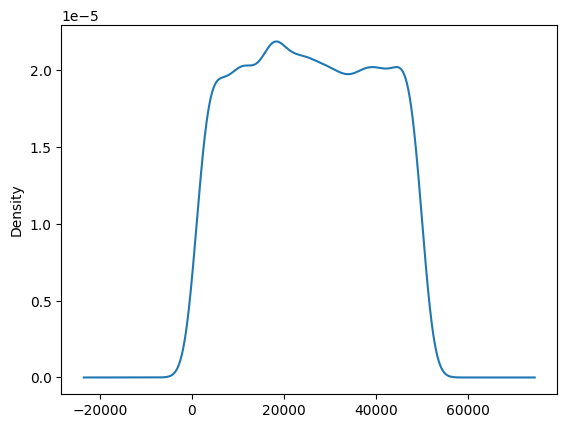

In [252]:
df['Billing Amount'].plot.density()

In [253]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df.corr()

,Age,Billing Amount,Room Number
Age,1.000000,-0.009483,-0.005371
Billing Amount,-0.009483,1.000000,-0.006160
Room Number,-0.005371,-0.006160,1.000000


In [254]:
columnas = ["Age", "Gender", "Medical Condition", "Medication", "Test Results"]
df = df[columnas].dropna()

In [255]:

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()



In [256]:
df.head()

,Age,Gender,Medical Condition,Medication,Test Results
0,81,Female,Diabetes,Aspirin,Inconclusive
1,35,Male,Asthma,Lipitor,Normal
2,61,Male,Obesity,Lipitor,Normal
3,49,Male,Asthma,Penicillin,Abnormal
4,51,Male,Arthritis,Paracetamol,Normal


One Hot Encoding

In [257]:
categoricas = ["Gender", "Medical Condition", "Medication", "Test Results"]

df_encoded = pd.get_dummies(df, columns=categoricas, drop_first=True)

In [258]:
df["Gender"] = df["Gender"].map({
    "Male": 1.0,
    "Female": 0.0
})

print(df["Gender"].head())
print(df["Gender"].dtype)

0    0.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: Gender, dtype: float64
float64


In [259]:
df["Medical Condition"] = df["Medical Condition"].astype("category").cat.codes.astype(float)


In [260]:
df["Medication"] = df["Medication"].astype("category").cat.codes.astype(float)

In [261]:
df["Test Results"] = df["Test Results"].astype("category").cat.codes.astype(float)

In [262]:
print(df.dtypes)

Age                    int64
Gender               float64
Medical Condition    float64
Medication           float64
Test Results         float64
dtype: object


In [263]:
print(df_encoded.head())

   Age  Gender_Male  Medical Condition_Asthma  Medical Condition_Cancer  \
0   81        False                     False                     False   
1   35         True                      True                     False   
2   61         True                     False                     False   
3   49         True                      True                     False   
4   51         True                     False                     False   

   Medical Condition_Diabetes  Medical Condition_Hypertension  \
0                        True                           False   
1                       False                           False   
2                       False                           False   
3                       False                           False   
4                       False                           False   

   Medical Condition_Obesity  Medication_Ibuprofen  Medication_Lipitor  \
0                      False                 False               False   
1         

In [264]:
l_column = list(df.columns) # Haciendo una lista de las columnas
len_feature = len(l_column) # Longitud de la lista de vectores de columna
l_column

['Age', 'Gender', 'Medical Condition', 'Medication', 'Test Results']

In [265]:
X = df[l_column[0:len_feature-1]]
y = df[l_column[len_feature-1]]

In [266]:
X.head()

,Age,Gender,Medical Condition,Medication
0,81,0.0,3.0,0.0
1,35,1.0,1.0,2.0
2,61,1.0,5.0,2.0
3,49,1.0,1.0,4.0
4,51,1.0,0.0,3.0


In [267]:
y.head()

,Test Results
0,1.0
1,2.0
2,2.0
3,0.0
4,2.0


In [268]:
from sklearn.model_selection import train_test_split

In [269]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

Modelo de regresión lineal

In [270]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [271]:
lm = LinearRegression()

In [272]:
lm.fit(X_train,y_train)

LinearRegression()

In [273]:
print("El término de intersección del modelo lineal:", lm.intercept_)

El término de intersección del modelo lineal: 0.9539075279542144


In [274]:
print("Los coeficientes del modelo lineal:", lm.coef_)

Los coeficientes del modelo lineal: [ 0.00064124 -0.00655061  0.00546632 -0.0091776 ]


In [275]:
#idict = {'Coefficients':lm.intercept_}
#idf = pd.DataFrame(data=idict,index=['Intercept'])
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=["Coefficients"])
#cdf=pd.concat([idf,cdf], axis=0)
cdf

,Coefficients
Age,0.000641
Gender,-0.006551
Medical Condition,0.005466
Medication,-0.009178


In [277]:
n = X_train.shape[0]
k = X_train.shape[1]

dfN = n - k - 1

train_pred = lm.predict(X_train)

train_error = (train_pred - y_train) ** 2
sum_error = np.sum(train_error)

mse = sum_error / dfN

# =========================
# SE DINÁMICO (CORRECTO)
# =========================
se = []

for col in X_train.columns:
    var_x = np.sum((X_train[col] - X_train[col].mean()) ** 2)
    se_i = np.sqrt(mse / var_x)
    se.append(se_i)

# =========================
# Ajuste seguro a cdf
# =========================
cdf = cdf.copy()  # evita problemas de referencia

cdf["Standard Error"] = se
cdf["t-statistic"] = cdf["Coefficients"] / cdf["Standard Error"]

cdf

,Coefficients,Standard Error,t-statistic
Age,0.000641,0.000467,1.372301
Gender,-0.006551,0.018298,-0.357987
Medical Condition,0.005466,0.005369,1.018039
Medication,-0.009178,0.006460,-1.420761


In [278]:
print("Por lo tanto, las características organizadas en orden de importancia para predecir el precio de la vivienda\n",'-'*90,sep='')
l=list(cdf.sort_values('t-statistic',ascending=False).index)
print(' > \n'.join(l))

Por lo tanto, las características organizadas en orden de importancia para predecir el precio de la vivienda
------------------------------------------------------------------------------------------
Age > 
Medical Condition > 
Gender > 
Medication


Text(0.5, 1.0, 'Medication vs. Medication')

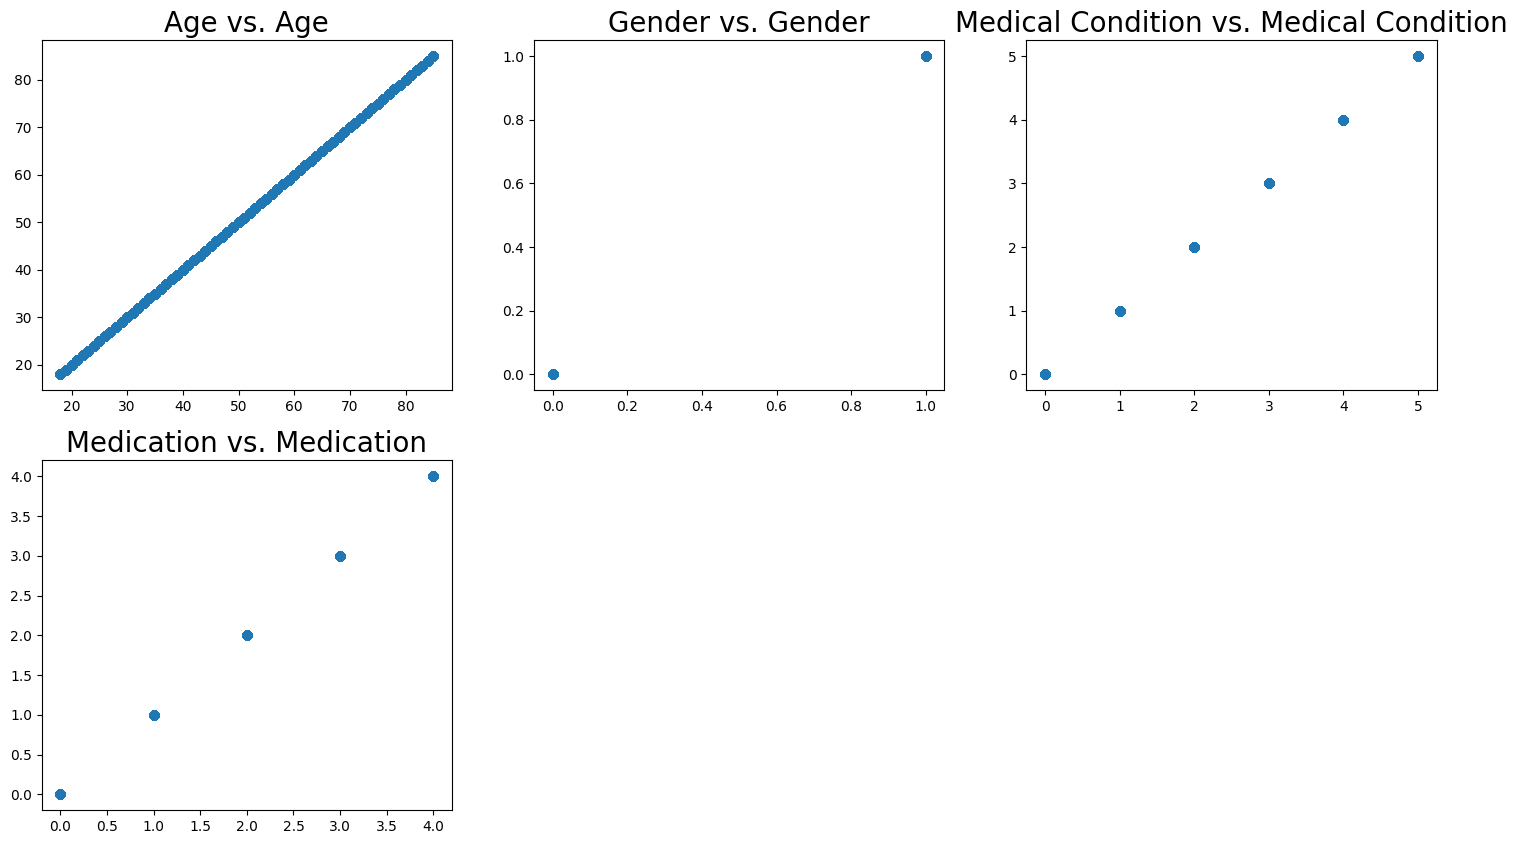

In [280]:
l=list(cdf.index)
from matplotlib import gridspec
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2,3)
#f, ax = plt.subplots(nrows=1,ncols=len(l), sharey=True)
ax0 = plt.subplot(gs[0])
ax0.scatter(df[l[0]],df['Age'])
ax0.set_title(l[0]+" vs. Age", fontdict={'fontsize':20})

ax1 = plt.subplot(gs[1])
ax1.scatter(df[l[1]],df['Gender'])
ax1.set_title(l[1]+" vs. Gender",fontdict={'fontsize':20})

ax2 = plt.subplot(gs[2])
ax2.scatter(df[l[2]],df['Medical Condition'])
ax2.set_title(l[2]+" vs. Medical Condition",fontdict={'fontsize':20})

ax3 = plt.subplot(gs[3])
ax3.scatter(df[l[3]],df['Medication'])
ax3.set_title(l[3]+" vs. Medication",fontdict={'fontsize':20})


JUSTIFICACIÓN:
}
Se observa una regresión lineal notoria, pese a que, tiene errores de codificación